<a href="https://colab.research.google.com/github/bharigopan/100-Days-Of-ML-Code/blob/master/01_introduction_networkx.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Undirected Graph

In [ ]:
import os

import networkx as nx
import pathlib
import matplotlib.pyplot as plt

_chapter = os.path.basename(os.getcwd())

if _chapter.startswith("Chapter"):
    BASE_FOLDER = os.environ.get("DATA_FOLDER", os.path.join(os.getcwd(), "..", "data"))
    DATA_DIR = pathlib.Path(BASE_FOLDER) / _chapter
else:
    BASE_FOLDER = os.environ.get("DATA_FOLDER", os.getcwd())
    DATA_DIR = pathlib.Path(BASE_FOLDER)

FIGURES_DIR = DATA_DIR / "figures"

default_edge_color = 'gray'
default_node_color = '#407cc9'
enhanced_node_color = '#f5b042'
enhanced_edge_color = '#cc2f04'

if not FIGURES_DIR.exists():
    FIGURES_DIR.mkdir(parents=True)

# draw a simple graph
def draw_graph(G, node_names={}, filename=None, node_size=50, layout = None, plot_weight=False):
    pos_nodes = nx.spring_layout(G) if layout is None else layout(G)
    node_names = {k: k for k, v in G.nodes.items()} if not node_names else node_names
    nx.draw(G, pos_nodes, with_labels=False, node_size=node_size, edge_color='gray')

    pos_attrs = {}
    for node, coords in pos_nodes.items():
        pos_attrs[node] = (coords[0], coords[1] + 0.08)

    nx.draw_networkx_labels(G, pos_attrs, labels=node_names, font_family='serif', font_size=20)

    if plot_weight:
        edge_labels=dict([((a,b,),d["weight"]) for a,b,d in G.edges(data=True)])
        nx.draw_networkx_edge_labels(G, pos_nodes, edge_labels=edge_labels)

    plt.axis('off')
    axis = plt.gca()
    axis.set_xlim([1.2*x for x in axis.get_xlim()])
    axis.set_ylim([1.2*y for y in axis.get_ylim()])

    if filename:
        plt.savefig(FIGURES_DIR / filename, format="png")


# draw enhanced path on the graph
def draw_enhanced_path(G, path_to_enhance, node_names={}, filename=None, layout = None):
    path_edges = list(zip(path_to_enhance,path_to_enhance[1:]))
    pos_nodes = nx.spring_layout(G) if layout is None else layout(G)

    plt.figure(figsize=(5,5),dpi=300)
    pos_nodes = nx.spring_layout(G)
    nx.draw(G, pos_nodes, with_labels=False, node_size=50, edge_color='gray')

    pos_attrs = {}
    for node, coords in pos_nodes.items():
        pos_attrs[node] = (coords[0], coords[1] + 0.08)

    nx.draw_networkx_labels(G, pos_attrs, labels=node_names, font_family='serif')
    nx.draw_networkx_edges(G,pos_nodes,edgelist=path_edges, edge_color='#cc2f04', style='dashed', width=2.0)

    plt.axis('off')
    axis = plt.gca()
    axis.set_xlim([1.2*x for x in axis.get_xlim()])
    axis.set_ylim([1.2*y for y in axis.get_ylim()])

    if filename:
        plt.savefig(FIGURES_DIR / filename, format="png")

In [ ]:
import networkx as nx
import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plt

import os
import sys

sys.path.append(f"{os.getcwd()}/..")
#from graph_utils import draw_graph
#from utils import draw_graph

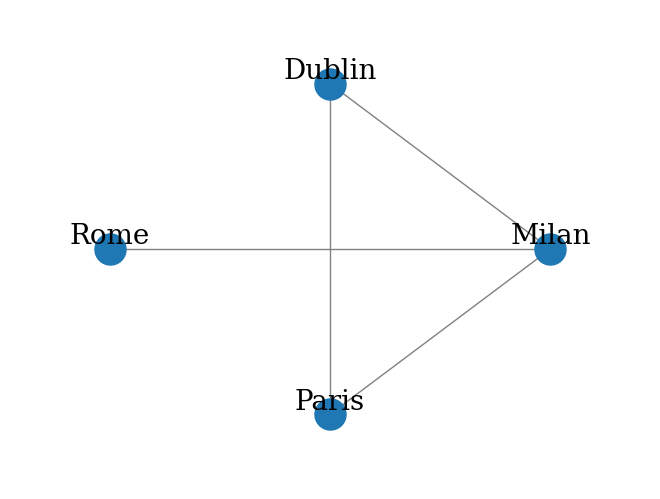

In [ ]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()
V = {'Dublin', 'Paris', 'Milan', 'Rome'}
E = [('Milan','Dublin'), ('Milan','Paris'), ('Paris','Dublin'), ('Milan','Rome')]
G.add_nodes_from(V)
G.add_edges_from(E)
draw_graph(G, layout=nx.shell_layout, node_size=500)

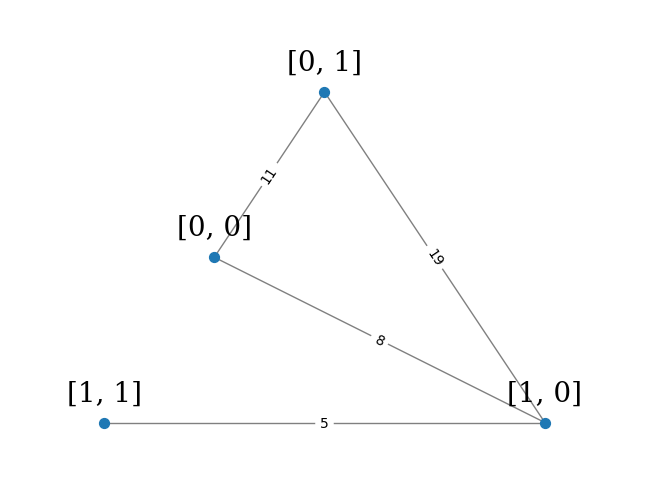

In [ ]:
G = nx.Graph()
V = {'Paris', 'Dublin','Milan', 'Rome'}
E = [('Paris','Dublin', 11), ('Paris','Milan', 8),
('Milan','Rome', 5), ('Milan','Dublin', 19)]
G.add_nodes_from(V)
G.add_weighted_edges_from(E)
node_position = {"Paris": [0,0], "Dublin": [0,1], "Milan": [1,0], "Rome":
[1,1]}
#node_position = nx.shell_layout(G)
#draw_graph(G, node_names=node_position, plot_weight=True, layout = nx.spiral_layout)
draw_graph(G, node_names=node_position, plot_weight=True, layout = nx.planar_layout)

In [ ]:
dict(G.nodes)

{'Rome': {}, 'Paris': {}, 'Milan': {}, 'Dublin': {}}

In [ ]:
print(f"V = {G.nodes}")
print(f"E = {G.edges}")

V = ['Rome', 'Paris', 'Milan', 'Dublin']
E = [('Rome', 'Milan'), ('Paris', 'Milan'), ('Paris', 'Dublin'), ('Milan', 'Dublin')]


In [ ]:
{G.degree(v): v for v in G.nodes}

{1: 'Rome', 2: 'Dublin', 3: 'Milan'}

In [ ]:
print(f"Graph Order: {G.number_of_nodes()}")
print(f"Graph Size: {G.number_of_edges()}")
print(f"Degree for nodes: { {v: G.degree(v) for v in G.nodes} }")
print(f"Neighbors for nodes: { {v: list(G.neighbors(v)) for v in G.nodes} }")

Graph Order: 4
Graph Size: 4
Degree for nodes: {'Rome': 1, 'Paris': 2, 'Milan': 3, 'Dublin': 2}
Neighbors for nodes: {'Rome': ['Milan'], 'Paris': ['Dublin', 'Milan'], 'Milan': ['Paris', 'Rome', 'Dublin'], 'Dublin': ['Paris', 'Milan']}


In [ ]:
ego_graph_milan = nx.ego_graph(G, "Milan")
print(f"Nodes: {ego_graph_milan.nodes}")
print(f"Edges: {ego_graph_milan.edges}")

Nodes: ['Rome', 'Paris', 'Milan', 'Dublin']
Edges: [('Rome', 'Milan'), ('Paris', 'Milan'), ('Paris', 'Dublin'), ('Milan', 'Dublin')]


In [ ]:
new_nodes = {'London', 'Madrid'}
new_edges = [('London','Rome'), ('Madrid','Paris')]
G.add_nodes_from(new_nodes)
G.add_edges_from(new_edges)
print(f"V = {G.nodes}")
print(f"E = {G.edges}")

V = ['Rome', 'Paris', 'Milan', 'Dublin', 'London', 'Madrid']
E = [('Rome', 'Milan'), ('Rome', 'London'), ('Paris', 'Dublin'), ('Paris', 'Milan'), ('Paris', 'Madrid'), ('Milan', 'Dublin')]


In [ ]:
node_remove = {'London', 'Madrid'}
G.remove_nodes_from(node_remove)
print(f"V = {G.nodes}")
print(f"E = {G.edges}")

V = ['Rome', 'Paris', 'Milan', 'Dublin']
E = [('Rome', 'Milan'), ('Paris', 'Dublin'), ('Paris', 'Milan'), ('Milan', 'Dublin')]


In [ ]:
node_edges = [('Milan','Dublin'), ('Milan','Paris')]
G.remove_edges_from(node_edges)
print(f"V = {G.nodes}")
print(f"E = {G.edges}")

V = ['Rome', 'Milan', 'Dublin', 'Paris']
E = [('Rome', 'Milan'), ('Dublin', 'Paris')]


In [ ]:
print(nx.to_edgelist(G))

[('Rome', 'Milan', {'weight': 5}), ('Paris', 'Dublin', {'weight': 11}), ('Paris', 'Milan', {'weight': 8}), ('Milan', 'Dublin', {'weight': 19})]


In [ ]:
print(nx.to_pandas_adjacency(G))

        Rome  Paris  Milan  Dublin
Rome     0.0    0.0    5.0     0.0
Paris    0.0    0.0    8.0    11.0
Milan    5.0    8.0    0.0    19.0
Dublin   0.0   11.0   19.0     0.0


## Directed Graph

In [ ]:
import networkx as nx
G = nx.DiGraph()
V = {'Dublin', 'Paris', 'Milan', 'Rome'}
E = [('Milan','Dublin'), ('Paris','Milan'), ('Paris','Dublin'), ('Milan','Rome')]
G.add_nodes_from(V)
G.add_edges_from(E)
print(nx.to_pandas_edgelist(G))
print(nx.to_pandas_adjacency(G))

  source  target
0  Paris   Milan
1  Paris  Dublin
2  Milan  Dublin
3  Milan    Rome
        Rome  Paris  Milan  Dublin
Rome     0.0    0.0    0.0     0.0
Paris    0.0    0.0    1.0     1.0
Milan    1.0    0.0    0.0     1.0
Dublin   0.0    0.0    0.0     0.0


In [ ]:
print(f"Indegree for nodes: { {v: G.in_degree(v) for v in G.nodes} }")
print(f"Outegree for nodes: { {v: G.out_degree(v) for v in G.nodes} }")

Indegree for nodes: {'Rome': 1, 'Paris': 0, 'Milan': 1, 'Dublin': 2}
Outegree for nodes: {'Rome': 0, 'Paris': 2, 'Milan': 2, 'Dublin': 0}


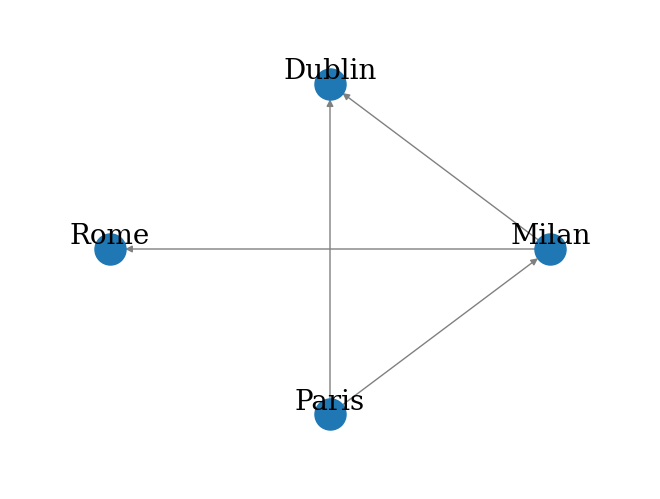

In [ ]:
draw_graph(G, layout=nx.shell_layout, node_size=500)

## Weighted Directed Graph

  source  target  weight
0  Paris  Dublin      11
1  Paris   Milan       8
2  Milan    Rome       5
3  Milan  Dublin      19
        Rome  Paris  Milan  Dublin
Rome     0.0    0.0    0.0     0.0
Paris    0.0    0.0    8.0    11.0
Milan    5.0    0.0    0.0    19.0
Dublin   0.0    0.0    0.0     0.0


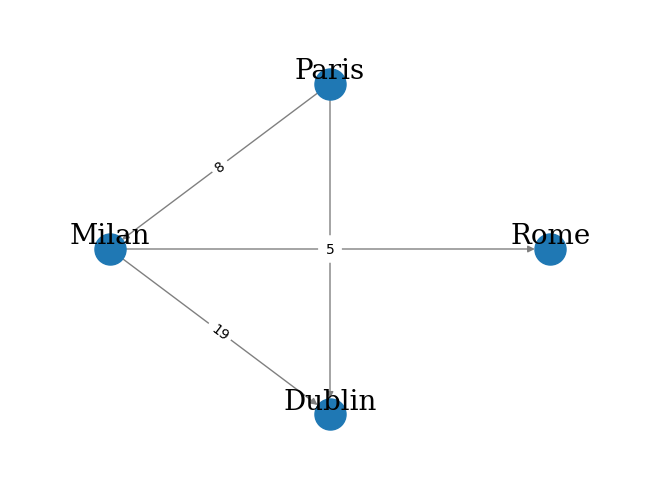

In [ ]:
import networkx as nx
G = nx.MultiDiGraph()
V = {'Paris', 'Dublin','Milan', 'Rome'}
E = [ ('Paris','Dublin', 11), ('Paris','Milan', 8),
     ('Milan','Rome', 5),('Milan','Dublin', 19)]
G.add_nodes_from(V)
G.add_weighted_edges_from(E)
draw_graph(G, layout=nx.circular_layout, node_size=500, plot_weight=True)
print(nx.to_pandas_edgelist(G))
print(nx.to_pandas_adjacency(G))

## Bipartite Graph

In [ ]:
n_nodes = 10
n_edges = 12
bottom_nodes = [ith for ith in range(n_nodes) if ith % 2 ==0]
top_nodes = [ith for ith in range(n_nodes) if ith % 2 ==1]
iter_edges = zip(
    np.random.choice(bottom_nodes, n_edges),
    np.random.choice(top_nodes, n_edges))
edges = pd.DataFrame([
    {"source": a, "target": b} for a, b in iter_edges])
B = nx.Graph()
B.add_nodes_from(bottom_nodes, bipartite=0)
B.add_nodes_from(top_nodes, bipartite=1)
B.add_edges_from([tuple(x) for x in edges.values])

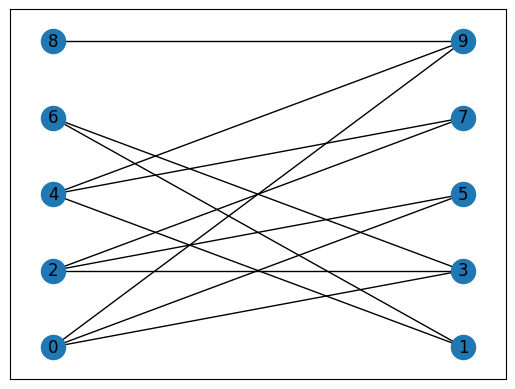

In [ ]:
from networkx.drawing.layout import bipartite_layout
pos = bipartite_layout(B, bottom_nodes)
nx.draw_networkx(B, pos=pos)

## Multi Graph

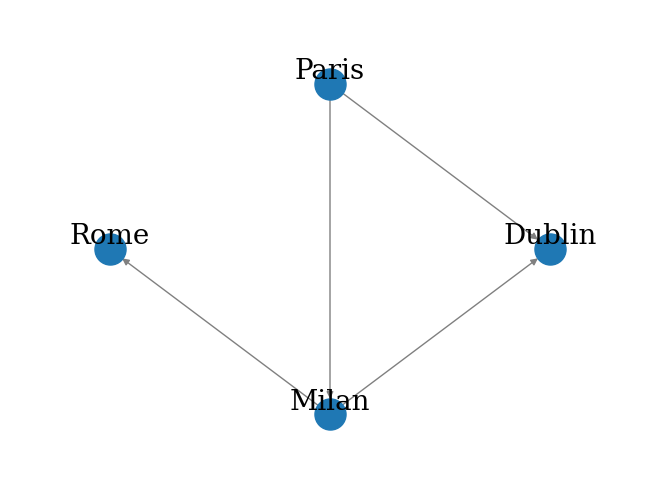

In [ ]:
import networkx as nx
directed_multi_graph = nx.MultiDiGraph()
V = {'Dublin', 'Paris', 'Milan', 'Rome'}
E = [('Milan','Dublin'), ('Milan','Dublin'), ('Paris','Milan'), ('Paris','Dublin'), ('Milan','Rome'), ('Milan','Rome')]
directed_multi_graph.add_nodes_from(V)
directed_multi_graph.add_edges_from(E)

draw_graph(G, layout=nx.shell_layout, node_size=500)